In [1]:
#Importing Liabraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
sns.set_style('whitegrid')

In [2]:
data = pd.read_csv(r"C:\Users\sarth\Documents\DS_f proj\3_FINAL UNIFIED EMP DATA.csv")

In [3]:
#converting date col to datetime format
data['StartDate'] = pd.to_datetime(data['StartDate'], format='%d-%b-%y')
data['DOB'] = pd.to_datetime(data['DOB'], format='%d-%m-%Y')

In [4]:
#Checking NULL values
data.isnull().sum()

EmpID                           0
FirstName                       0
LastName                        0
StartDate                       0
Position                        0
Supervisor                      0
ADEmail                         0
BusinessUnit                    0
EmployeeStatus                  0
EmployeeType                    0
PayZone                         0
EmployeeClassificationType      0
DepartmentType                  0
DOB                             0
State                           0
Gender                          0
Pincode                       500
Performance                     0
Current Emp Rating              0
CompanyName                     0
dtype: int64

In [5]:
#filling # Fill missing Pincode values with 0
data['Pincode'] = data['Pincode'].fillna(0)

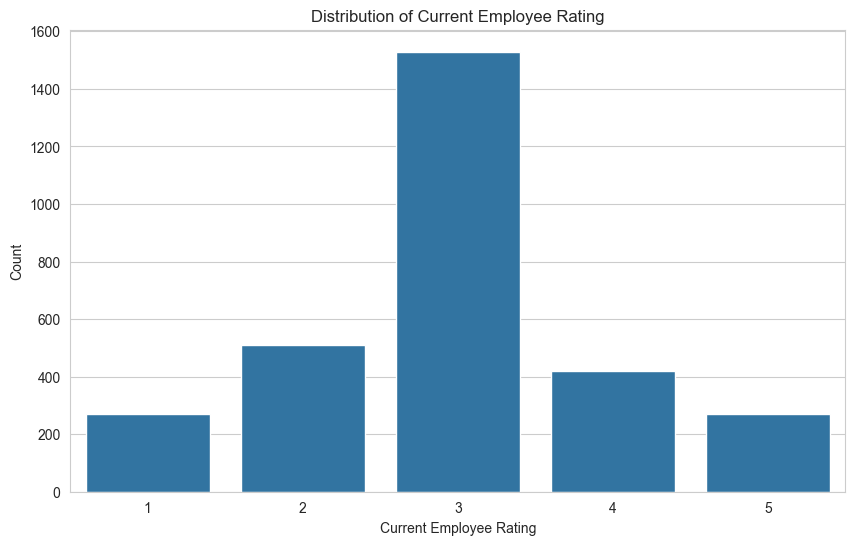

In [6]:
# Distribution of Current Emp Rating
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='Current Emp Rating')
plt.title('Distribution of Current Employee Rating')
plt.xlabel('Current Employee Rating')
plt.ylabel('Count')
plt.show()

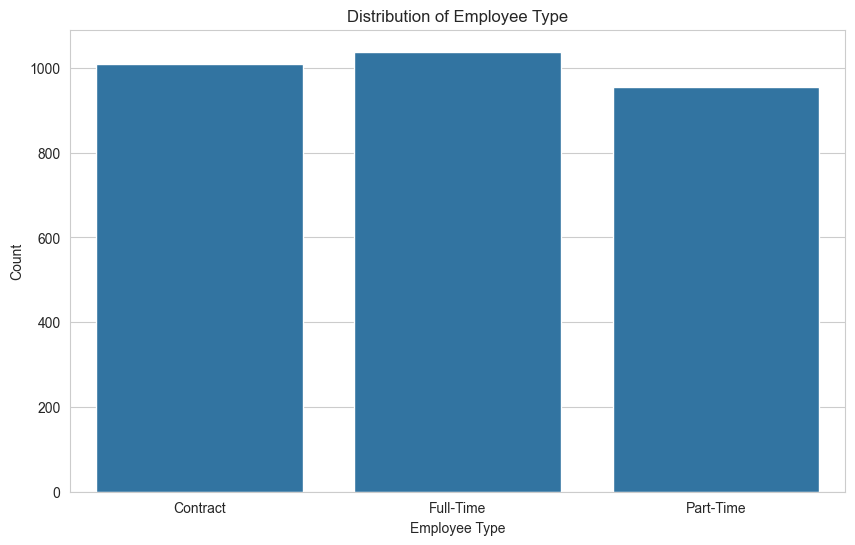

In [7]:
# Distribution of Employee Type
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='EmployeeType')
plt.title('Distribution of Employee Type')
plt.xlabel('Employee Type')
plt.ylabel('Count')
plt.show()

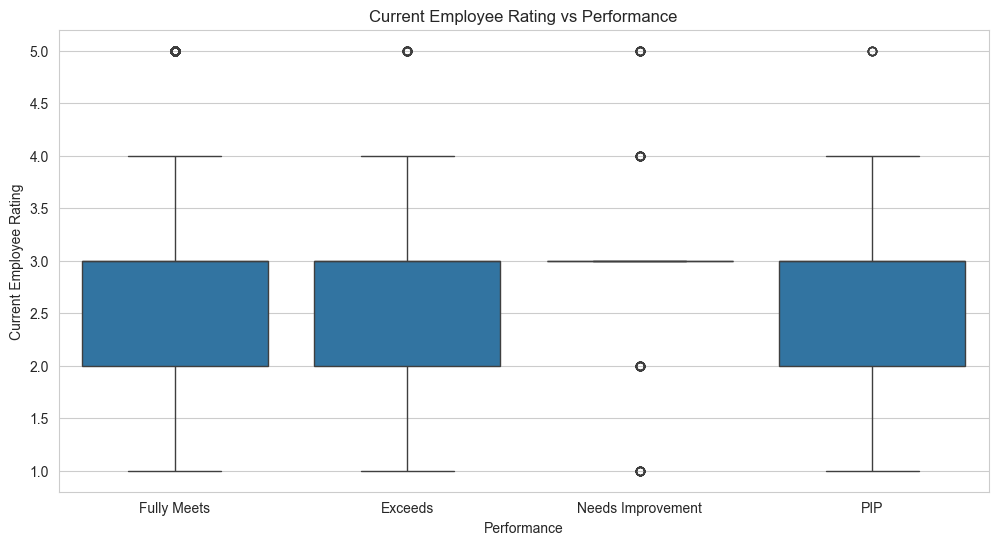

In [8]:
# Current Emp Rating vs Performance
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='Performance ', y='Current Emp Rating')
plt.title('Current Employee Rating vs Performance')
plt.xlabel('Performance')
plt.ylabel('Current Employee Rating')
plt.show()

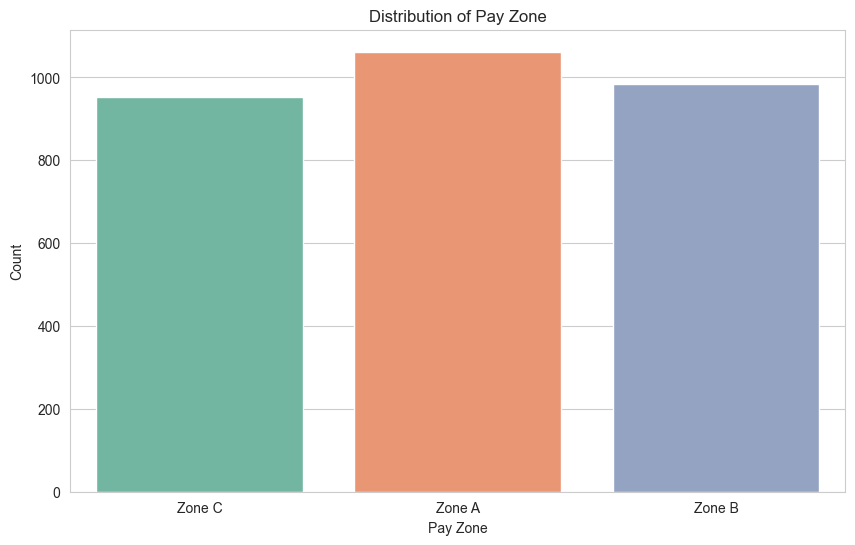

In [9]:
# Custom color palette
custom_palette = sns.color_palette("Set2", n_colors=len(data['PayZone'].unique()))

# Distribution of PayZone - Countplot with custom colors and hue
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='PayZone', hue='PayZone', palette=custom_palette, dodge=False, legend=False)
plt.title('Distribution of Pay Zone')
plt.xlabel('Pay Zone')
plt.ylabel('Count')
plt.show()

In [10]:
# Calculate age of employees

data['Age'] = (datetime.now() - data['DOB']).dt.days // 365

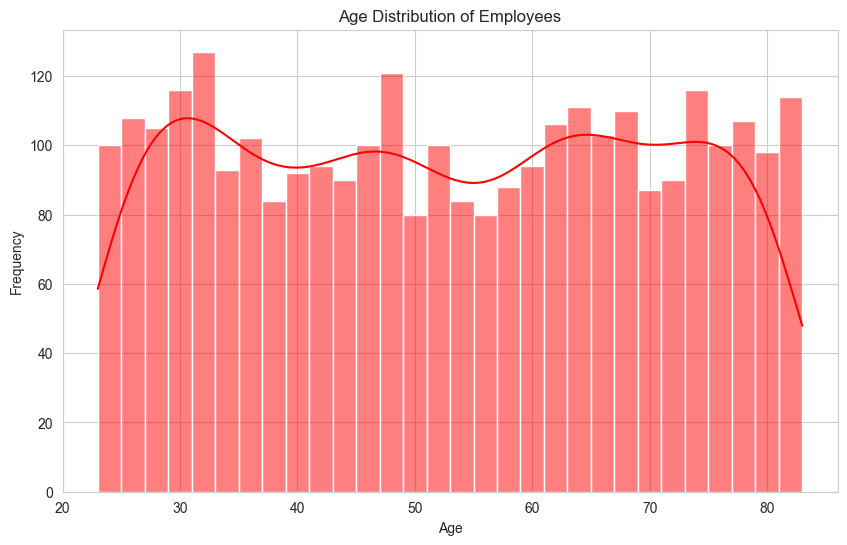

In [11]:
# Age Distribution of Employees
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Age', bins=30, kde=True, color='red') #kde = kernel density est
plt.title('Age Distribution of Employees')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

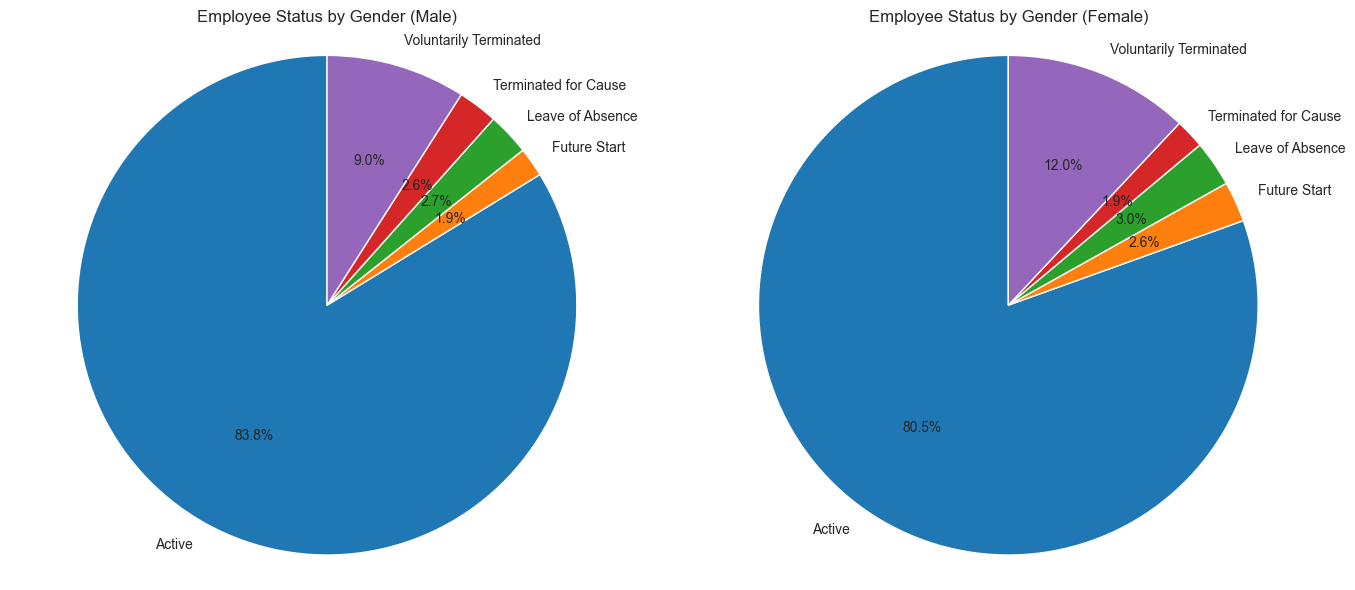

In [12]:
data_counts = data.groupby(['EmployeeStatus', 'Gender']).size().unstack().fillna(0)

# Creating subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plotting the first pie chart (for Male)
axes[0].pie(data_counts['Male'], labels=data_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Employee Status by Gender (Male)')

# Plotting the second pie chart (for Female)
axes[1].pie(data_counts['Female'], labels=data_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Employee Status by Gender (Female)')

# Equal aspect ratio 
for ax in axes:
    ax.axis('equal')

plt.tight_layout()
plt.show()

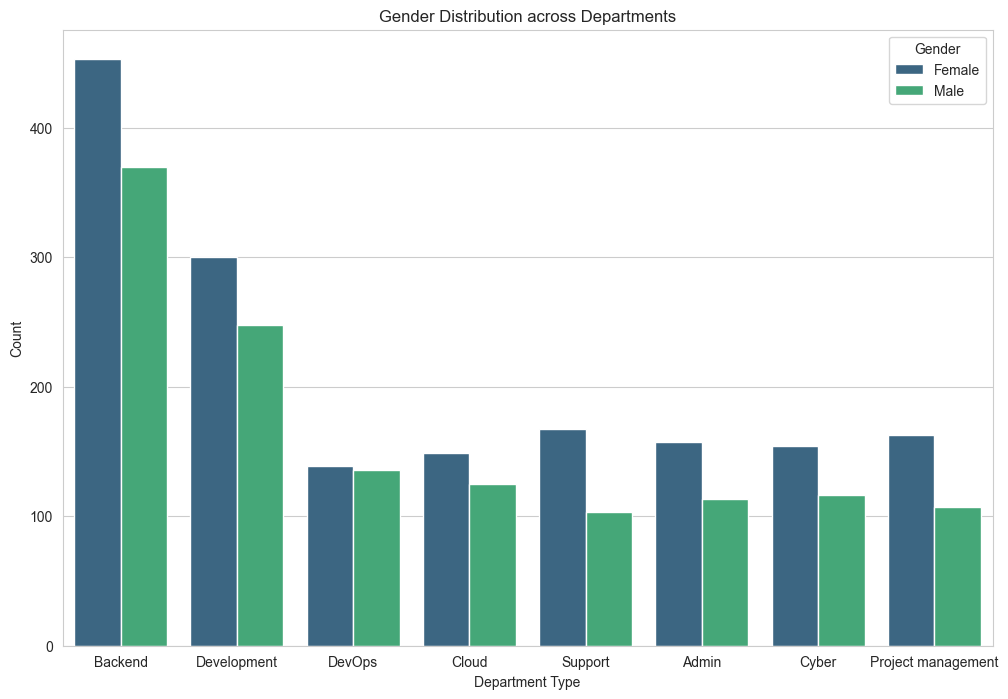

In [13]:
plt.figure(figsize=(12, 8))
sns.countplot(data=data, x='DepartmentType', hue='Gender',palette='viridis')
plt.title('Gender Distribution across Departments')
plt.xlabel('Department Type')
plt.ylabel('Count')
plt.legend
plt.show()

In [14]:
# Calculate tenure of employees

data['Tenure'] = (datetime.now() - data['StartDate']).dt.days // 365

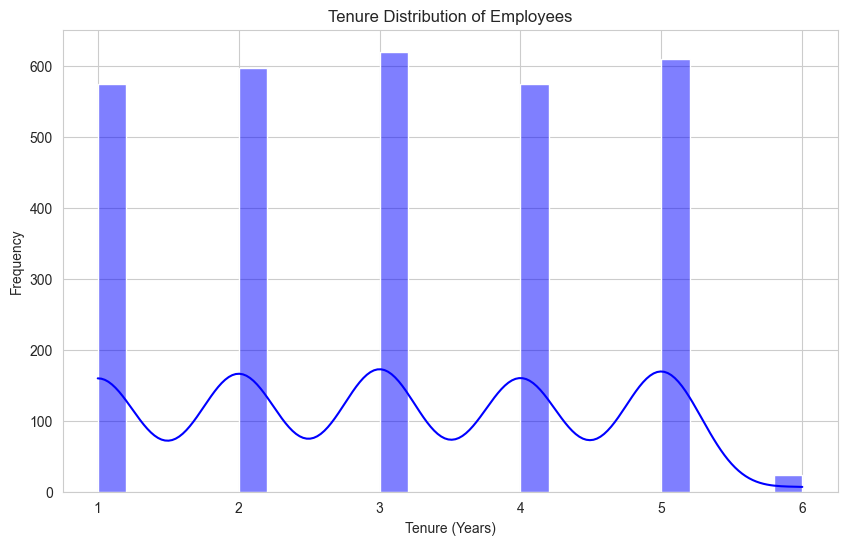

In [15]:
# Tenure of Employees
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Tenure', bins=25, kde=True, color='blue')
plt.title('Tenure Distribution of Employees')
plt.xlabel('Tenure (Years)')
plt.ylabel('Frequency')
plt.show()